### sigmoid
- với perceptron thì nó là công thức với $$step(wx+b)$$
- nhưng step đó thì nó chỉ có 2 giá trị 0 1 nên đưa ra 1 khái niệm mới là sigmoid 
- nó là 1 miền giá trị liên tục từ 0->1 có thể hiểu nó 1 cách nâng cấp của cái củ  
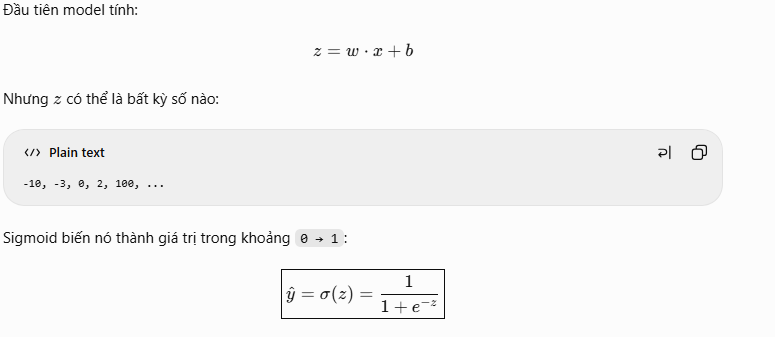

### Logloss (Binary Cross-Entropy)
- Sau khi có kết quả tuyến tính, ta đưa qua hàm Sigmoid để thu được xác suất dự đoán $\hat{y}$.
- **LogLoss** có nhiệm vụ đánh giá độ lệch giữa dự đoán ($\hat{y}$) và nhãn thực tế ($y$), giá trị **càng nhỏ càng tốt**.

---

#### 1. Tính toán giá trị tuyến tính $z$
$$z = w \cdot x + b = 2$$

#### 2. Áp dụng hàm kích hoạt Sigmoid để tính $\hat{y}$
Đưa $z = 2$ vào hàm Sigmoid để chuyển về khoảng xác suất $[0, 1]$:
$$\hat{y} = \sigma(z) = \frac{1}{1 + e^{-z}} = \frac{1}{1 + e^{-2}} \approx 0.8808$$

#### 3. Đánh giá bằng LogLoss
Công thức tổng quát:
$$L = -[y \ln(\hat{y}) + (1 - y) \ln(1 - \hat{y})]$$

Thay $\hat{y} \approx 0.8808$ vào công thức cho 2 trường hợp nhãn thực tế $y$:

- **Kịch bản 1: Nhãn thực tế $y = 1$ (Dự đoán đúng hướng)**
  $$L = -[1 \cdot \ln(0.8808) + (1 - 1) \cdot \ln(1 - 0.8808)] = -\ln(0.8808) \approx 0.1269$$
  *(Mất mát nhỏ $\rightarrow$ Dự đoán tốt)*

- **Kịch bản 2: Nhãn thực tế $y = 0$ (Dự đoán sai hướng)**
  $$L = -[0 \cdot \ln(0.8808) + (1 - 0) \cdot \ln(1 - 0.8808)] = -\ln(1 - 0.8808) = -\ln(0.1192) \approx 2.1269$$
  *(Mất mát lớn $\rightarrow$ Dự đoán phạt nặng)*

### Logistic Trick
- Lấy một điểm dữ liệu → xem model dự đoán nó thế nào → chỉnh \(w,b\) một chút để prediction tiến gần label thật hơn.

### Cập nhật trọng số (Gradient Descent Update Rule)

Sau khi tính được sai số dự đoán, ta cập nhật tham số $w$ và $b$ theo quy tắc:

$$w' = w + h(y - \hat{y})x$$

$$b' = b + h(y - \hat{y})$$

**Ý nghĩa các thành phần:**
- $x$: Đầu vào (input feature) của điểm dữ liệu đang xét.
- $y$: Nhãn thực tế ($0$ hoặc $1$).
- $\hat{y} = \sigma(w \cdot x + b)$: Xác suất dự đoán từ hàm Sigmoid.
- $e = (y - \hat{y})$: Sai số (Residual). Nếu đoán đúng ($y \approx \hat{y}$), sai số gần bằng 0 nên gần như không thay đổi trọng số.
- $h$: Tốc độ học (Learning rate - thường ký hiệu là $\alpha$ hoặc $\eta$).
- $w', b'$: Trọng số và hệ số chệch mới sau khi cập nhật.

Weights: [1.77578744 1.76360397]
Bias: -9.468446523447497

Probability:
[0.00265393 0.01528544 0.01546991 0.99088899 0.99842626 0.99844528]

Prediction:
[0 0 0 1 1 1]

Actual:
[0 0 0 1 1 1]

Final Log Loss:
0.007655903253477166


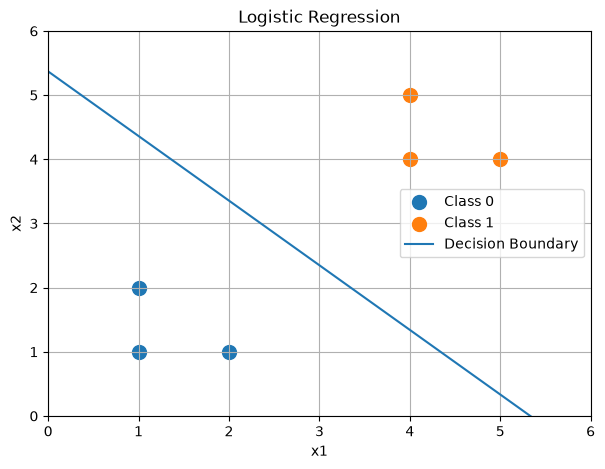

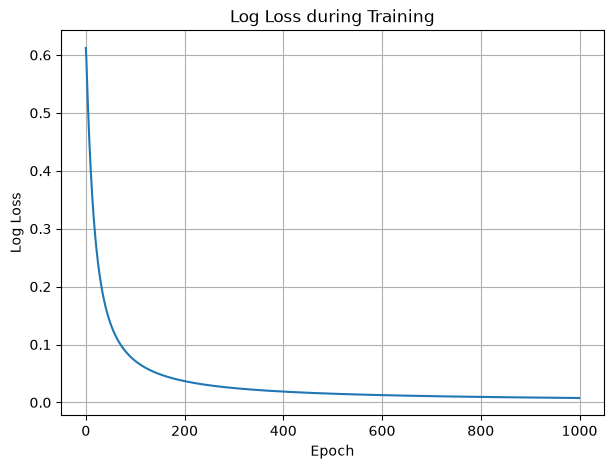

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. DATA
# ==========================================

X = np.array([
    [1, 1],
    [1, 2],
    [2, 1],
    [4, 4],
    [4, 5],
    [5, 4]
], dtype=float)

y = np.array([0, 0, 0, 1, 1, 1])


# ==========================================
# 2. SIGMOID
# ==========================================

def sigmoid(z):
    return 1 / (1 + np.exp(-z))


# ==========================================
# 3. LOG LOSS
# ==========================================

def log_loss(y, y_hat):
    eps = 1e-15

    # tránh log(0)
    y_hat = np.clip(y_hat, eps, 1 - eps)

    return -np.mean(
        y * np.log(y_hat)
        + (1 - y) * np.log(1 - y_hat)
    )


# ==========================================
# 4. KHỞI TẠO MODEL
# ==========================================

w = np.array([0.0, 0.0])
b = 0.0

learning_rate = 0.1
epochs = 1000

loss_history = []


# ==========================================
# 5. TRAIN - LOGISTIC TRICK
# ==========================================

for epoch in range(epochs):

    for xi, yi in zip(X, y):

        # score
        z = np.dot(w, xi) + b

        # sigmoid
        y_hat = sigmoid(z)

        # Logistic Trick
        error = yi - y_hat

        w = w + learning_rate * error * xi
        b = b + learning_rate * error

    # tính loss của toàn bộ dataset
    predictions = sigmoid(X @ w + b)

    loss = log_loss(y, predictions)

    loss_history.append(loss)


# ==========================================
# 6. KẾT QUẢ
# ==========================================

print("Weights:", w)
print("Bias:", b)

probabilities = sigmoid(X @ w + b)

predictions = (probabilities >= 0.5).astype(int)

print("\nProbability:")
print(probabilities)

print("\nPrediction:")
print(predictions)

print("\nActual:")
print(y)

print("\nFinal Log Loss:")
print(log_loss(y, probabilities))


# ==========================================
# 7. VISUALIZE DECISION BOUNDARY
# ==========================================

plt.figure(figsize=(7, 5))

# Class 0
plt.scatter(
    X[y == 0, 0],
    X[y == 0, 1],
    label="Class 0",
    s=100
)

# Class 1
plt.scatter(
    X[y == 1, 0],
    X[y == 1, 1],
    label="Class 1",
    s=100
)


# Decision boundary:
#
# w1*x1 + w2*x2 + b = 0
#
# =>
#
# x2 = -(w1*x1 + b) / w2

x1_line = np.linspace(0, 6, 100)

x2_line = -(w[0] * x1_line + b) / w[1]

plt.plot(
    x1_line,
    x2_line,
    label="Decision Boundary"
)

plt.xlabel("x1")
plt.ylabel("x2")

plt.title("Logistic Regression")

plt.xlim(0, 6)
plt.ylim(0, 6)

plt.legend()
plt.grid()

plt.show()


# ==========================================
# 8. VISUALIZE LOG LOSS
# ==========================================

plt.figure(figsize=(7, 5))

plt.plot(loss_history)

plt.xlabel("Epoch")
plt.ylabel("Log Loss")

plt.title("Log Loss during Training")

plt.grid()

plt.show()

In [1]:
import numpy as np
import scipy
import sklearn
print("numpy:", np.__version__)
print("scipy:", scipy.__version__)
print("sklearn:", sklearn.__version__)


numpy: 2.5.3
scipy: 1.18.1
sklearn: 1.9.1


Weights: [[0.78278778 0.78278778]]
Bias: [-4.4328977]
Prediction:
[0 0 0 1 1 1]

Probability:
[[0.94620721 0.05379279]
 [0.88939089 0.11060911]
 [0.88939089 0.11060911]
 [0.13830923 0.86169077]
 [0.06835785 0.93164215]
 [0.06835785 0.93164215]]

Probability class 1:
[0.05379279 0.11060911 0.11060911 0.86169077 0.93164215 0.93164215]

Log Loss: 0.09670039896274159


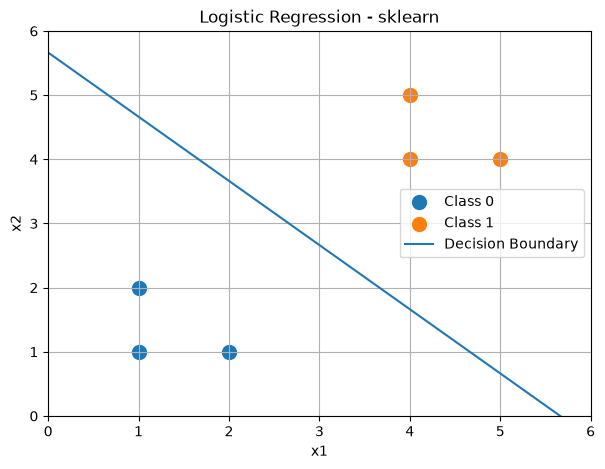

In [2]:
## sklearn

import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss


# ==========================================
# 1. DATA
# ==========================================

X = np.array([
    [1, 1],
    [1, 2],
    [2, 1],
    [4, 4],
    [4, 5],
    [5, 4]
])

y = np.array([0, 0, 0, 1, 1, 1])


# ==========================================
# 2. TẠO MODEL
# ==========================================

model = LogisticRegression()

# Train
model.fit(X, y)


# ==========================================
# 3. XEM w VÀ b
# ==========================================

print("Weights:", model.coef_)
print("Bias:", model.intercept_)


# ==========================================
# 4. PREDICT
# ==========================================

y_pred = model.predict(X)

print("Prediction:")
print(y_pred)


# ==========================================
# 5. PROBABILITY (SIGMOID)
# ==========================================

y_prob = model.predict_proba(X)

print("\nProbability:")
print(y_prob)


# probability của class 1
prob_class_1 = y_prob[:, 1]

print("\nProbability class 1:")
print(prob_class_1)


# ==========================================
# 6. LOG LOSS
# ==========================================

loss = log_loss(y, prob_class_1)

print("\nLog Loss:", loss)


# ==========================================
# 7. VISUALIZE
# ==========================================

plt.figure(figsize=(7, 5))

# class 0
plt.scatter(
    X[y == 0, 0],
    X[y == 0, 1],
    s=100,
    label="Class 0"
)

# class 1
plt.scatter(
    X[y == 1, 0],
    X[y == 1, 1],
    s=100,
    label="Class 1"
)


# ==========================================
# DECISION BOUNDARY
#
# w1*x1 + w2*x2 + b = 0
# ==========================================

w1 = model.coef_[0][0]
w2 = model.coef_[0][1]

b = model.intercept_[0]

x1_line = np.linspace(0, 6, 100)

x2_line = -(w1 * x1_line + b) / w2

plt.plot(
    x1_line,
    x2_line,
    label="Decision Boundary"
)


plt.xlabel("x1")
plt.ylabel("x2")

plt.title("Logistic Regression - sklearn")

plt.xlim(0, 6)
plt.ylim(0, 6)

plt.legend()
plt.grid()

plt.show()

In [1]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss

model = LogisticRegression()
print(model)

LogisticRegression()
